# AlphaLens Event Return Targets

This notebook constructs the supervised-learning label for each earnings call and SEC filing. The label measures medium-term post-event performance relative to SPY.

$$r_{stock,30} = \frac{P_{stock,t+30}}{P_{stock,t}} - 1$$

$$r_{SPY,30} = \frac{P_{SPY,t+30}}{P_{SPY,t}} - 1$$

$$excess\\ return_{30} = r_{stock,30} - r_{SPY,30}$$

The anchor $t$ is the adjusted close of the first trading session strictly after the event date. The target date is 30 trading sessions after that anchor, using the same two dates for SPY. This conservative rule avoids guessing whether date-only events occurred before or after market hours.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.dataset import (
    build_modeling_targets,
    summarize_targets,
    validate_target_dataset,
)

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', context='notebook')

## Build and validate the target dataset

The reusable pipeline loads events and adjusted prices from PostgreSQL. Events without enough future data remain in the dataset with an explicit reason.

In [3]:
HORIZON = 30
targets = build_modeling_targets(horizon=HORIZON)
checks = validate_target_dataset(targets, horizon=HORIZON)
checks

{'rows': 758,
 'labeled_rows': 724,
 'duplicate_event_keys': 0,
 'anchor_not_after_event': 0,
 'target_not_after_anchor': 0,
 'missing_labeled_targets': 0}

In [4]:
summary = summarize_targets(targets, horizon=HORIZON)
display(summary.style.format({
    'coverage': '{:.1%}',
    'mean_stock_return': '{:.2%}',
    'mean_spy_return': '{:.2%}',
    'mean_excess_return': '{:.2%}',
    'median_excess_return': '{:.2%}',
    'positive_excess_rate': '{:.1%}',
}))

,event_source,events,targets_available,targets_unavailable,coverage,mean_stock_return,mean_spy_return,mean_excess_return,median_excess_return,positive_excess_rate
0,earnings_call,359,342,17,95.3%,2.28%,1.85%,0.43%,0.45%,52.3%
1,sec_filing,399,382,17,95.7%,1.80%,1.63%,0.18%,0.37%,51.8%


## Censored recent events

Recent events do not yet have 30 later trading sessions. They are censored, not negative examples, and must be excluded from training until their labels mature.

In [5]:
unavailable = targets.loc[~targets['target_available']]
display(unavailable['target_error'].value_counts().rename_axis('reason').to_frame('events'))
display(unavailable[[
    'event_key', 'ticker', 'event_date', 'anchor_trading_date', 'target_error'
]].sort_values('event_date', ascending=False).head(12))

,events
reason,
incomplete_forward_window,34


,event_key,ticker,event_date,anchor_trading_date,target_error
757,sec_filing:0000731766-26-000197,UNH,2026-08-10,2026-08-11,incomplete_forward_window
756,sec_filing:0001628280-26-054343,JPM,2026-08-06,2026-08-07,incomplete_forward_window
755,sec_filing:0000093410-26-000167,CVX,2026-08-06,2026-08-07,incomplete_forward_window
754,sec_filing:0000018230-26-000046,CAT,2026-08-05,2026-08-06,incomplete_forward_window
753,sec_filing:0000080424-26-000103,PG,2026-08-04,2026-08-05,incomplete_forward_window
752,earnings_call:326,CAT,2026-08-04,2026-08-05,incomplete_forward_window
751,sec_filing:0000886982-26-000297,GS,2026-08-03,2026-08-04,incomplete_forward_window
750,earnings_call:234,CVX,2026-07-31,2026-08-03,incomplete_forward_window
749,sec_filing:0000070858-26-000394,BAC,2026-07-31,2026-08-03,incomplete_forward_window
748,sec_filing:0001018724-26-000026,AMZN,2026-07-31,2026-08-03,incomplete_forward_window


## Auditable labels

Every label retains its event date, exact stock/SPY prices, anchor date, and target date. These columns make off-by-one and benchmark-alignment errors inspectable.

In [6]:
labeled = targets.loc[targets['target_available']].copy()
sample_columns = [
    'event_key', 'ticker', 'event_date', 'anchor_trading_date',
    'target_trading_date', 'anchor_adjusted_close',
    'target_adjusted_close', 'stock_forward_return_30d',
    'spy_forward_return_30d', 'excess_return_30d',
]
display(labeled[sample_columns].tail(10))

,event_key,ticker,event_date,anchor_trading_date,target_trading_date,anchor_adjusted_close,target_adjusted_close,stock_forward_return_30d,spy_forward_return_30d,excess_return_30d
714,earnings_call:235,CVX,2026-05-01,2026-05-04,2026-06-16,188.886414,178.551743,-0.054714,0.045013,-0.099727
715,sec_filing:0000886982-26-000118,GS,2026-05-01,2026-05-04,2026-06-16,899.306580,1090.670044,0.212790,0.045013,0.167777
716,sec_filing:0001628280-26-029344,JPM,2026-05-01,2026-05-04,2026-06-16,306.270264,329.654938,0.076353,0.045013,0.031340
717,sec_filing:0000731766-26-000127,UNH,2026-05-05,2026-05-06,2026-06-18,365.194214,400.959991,0.097936,0.020214,0.077722
718,sec_filing:0000018230-26-000021,CAT,2026-05-06,2026-05-07,2026-06-22,894.031494,1020.387085,0.141332,0.020131,0.121201
719,sec_filing:0000093410-26-000113,CVX,2026-05-07,2026-05-08,2026-06-23,178.414551,174.457474,-0.022179,-0.002915,-0.019264
720,sec_filing:0001045810-26-000052,NVDA,2026-05-20,2026-05-21,2026-07-07,219.254456,196.929993,-0.101820,0.009312,-0.111132
721,earnings_call:288,COST,2026-05-28,2026-05-29,2026-07-14,954.801941,920.286804,-0.036149,-0.003586,-0.032563
722,sec_filing:0000104169-26-000102,WMT,2026-05-29,2026-06-01,2026-07-15,114.326302,112.261246,-0.018063,-0.002354,-0.015709
723,sec_filing:0000909832-26-000051,COST,2026-06-03,2026-06-04,2026-07-20,970.806458,934.314514,-0.037589,-0.017288,-0.020302


## Target distribution

The regression label remains continuous. A positive/negative direction can also be derived for diagnostic classification metrics without discarding return magnitude.

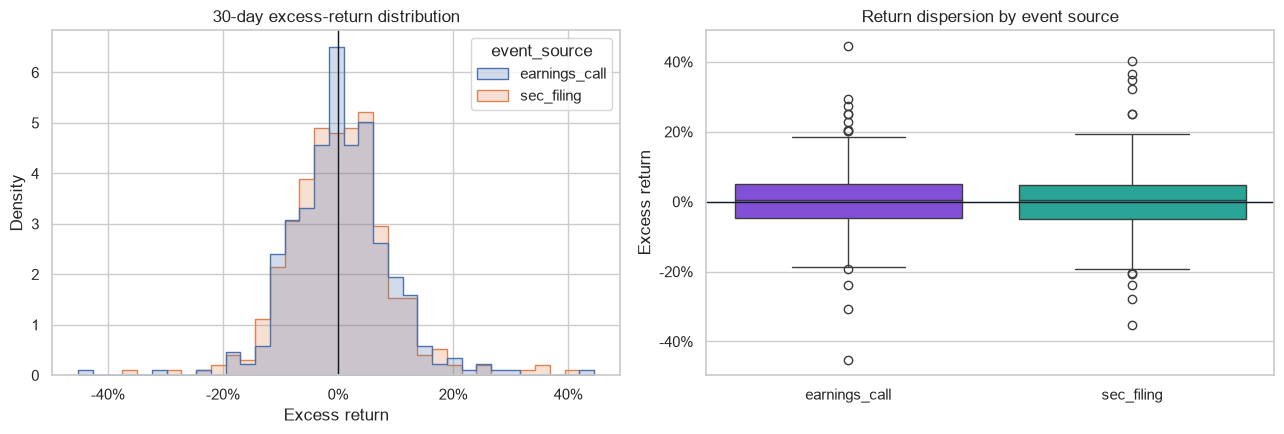

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(
    data=labeled, x='excess_return_30d', hue='event_source',
    bins=35, element='step', stat='density', common_norm=False, ax=axes[0]
)
axes[0].axvline(0, color='#111827', linewidth=1)
axes[0].set(title='30-day excess-return distribution', xlabel='Excess return')
axes[0].xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')

sns.boxplot(
    data=labeled, x='event_source', y='excess_return_30d',
    hue='event_source', legend=False, palette=['#7c3aed', '#14b8a6'], ax=axes[1]
)
axes[1].axhline(0, color='#111827', linewidth=1)
axes[1].set(title='Return dispersion by event source', xlabel='', ylabel='Excess return')
axes[1].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.tight_layout()
plt.show()

## Coverage by company

In [8]:
ticker_summary = (
    labeled.groupby('ticker', as_index=False)
    .agg(
        labeled_events=('event_key', 'size'),
        mean_excess_return=('excess_return_30d', 'mean'),
        positive_excess_rate=('excess_return_30d', lambda values: values.gt(0).mean()),
    )
    .sort_values('ticker')
)
display(ticker_summary.style.format({
    'mean_excess_return': '{:.2%}',
    'positive_excess_rate': '{:.1%}',
}))

,ticker,labeled_events,mean_excess_return,positive_excess_rate
0,AAPL,37,0.14%,54.1%
1,AMZN,36,-0.45%,50.0%
2,BA,36,-0.82%,44.4%
3,BAC,36,-1.11%,50.0%
4,CAT,35,2.41%,74.3%
5,COST,38,1.54%,57.9%
6,CVX,36,-0.52%,41.7%
7,GOOGL,36,0.63%,44.4%
8,GS,36,1.48%,58.3%
9,JNJ,35,-0.45%,40.0%


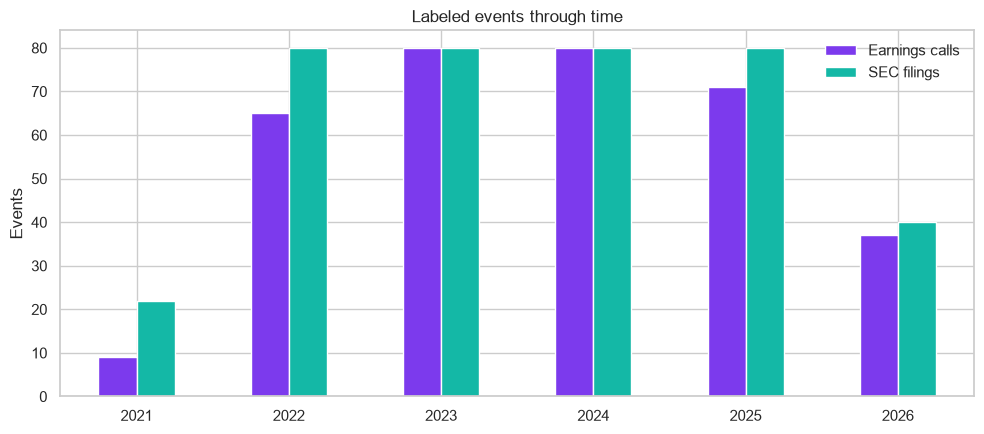

In [9]:
annual_counts = (
    labeled.assign(year=labeled['event_date'].dt.year)
    .groupby(['year', 'event_source'])
    .size()
    .unstack(fill_value=0)
)
ax = annual_counts.plot(
    kind='bar', figsize=(10, 4.5), color=['#7c3aed', '#14b8a6']
)
ax.set(title='Labeled events through time', xlabel='', ylabel='Events')
ax.legend(['Earnings calls', 'SEC filings'], frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Leakage controls for modeling

1. Features will be computed only from information available no later than the anchor date.
2. Training, validation, and test sets will be chronological rather than random.
3. Fold boundaries will purge at least 30 trading days so overlapping target windows cannot cross from training into evaluation.
4. Recent unlabeled events will be retained for future inference but excluded from training.
5. Multiple events for one company remain separate observations; later diagnostics will measure dependence and performance by ticker.

## Decision for the next stage

The target is sufficiently covered and approximately directionally balanced for baseline modeling. The next step is point-in-time feature engineering: momentum, volatility, moving averages, volume, event metadata, and aggregated FinBERT signals. Earnings surprise remains excluded until its own timestamped source exists.